# Heart Disease Prediction

**CodeAlpha Machine Learning Internship — Task 4**
By Aamina Khan

This project predicts whether a patient is at risk of heart disease using machine learning classification models trained on clinical and demographic data.

**Dataset used:** UCI Heart Disease (Cleveland subset)

**Algorithms compared:**
- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost (gradient boosting)

**Goal:** Build a reliable classifier that can help screen patients for heart disease risk based on standard health indicators (age, blood pressure, cholesterol, chest pain type, etc.).

**Step 1: Import Libraries**

We import all libraries needed throughout the project:
- pandas, numpy — for data handling
- matplotlib, seaborn — for visualizations
- scikit-learn — for splitting, scaling, training, and evaluating models
- xgboost — for the gradient boosting model

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# XGBoost - install if not already available
!pip install xgboost -q
from xgboost import XGBClassifier

**Step 2: Mount Google Drive**

We mount Google Drive to access the heart disease dataset stored in our project folder.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Step 3: Load and Preview the Dataset**

We load the heart disease dataset and inspect its structure:
- Shape (rows × columns)
- First few rows
- Column data types
- Basic statistics

This tells us what we're working with before any preprocessing.

In [4]:
# Load dataset from Google Drive
heart = pd.read_csv('/content/drive/MyDrive/CSV files for projects/heart_disease_uci.csv')

# Quick overview
print("Dataset shape:", heart.shape)
print("\nFirst 5 rows:")
print(heart.head())

print("\nColumn data types:")
print(heart.dtypes)

print("\nBasic statistics:")
print(heart.describe())

Dataset shape: (920, 16)

First 5 rows:
   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    

**Step 4: Drop Unnecessary Columns**

We remove columns that don't help with prediction:
- id — just a row identifier, has no medical meaning
- dataset — tells us which hospital the data came from, not a health feature

In [5]:
# Drop
heart = heart.drop(['id', 'dataset'], axis=1)

# Confirm the new shape
print("New shape:", heart.shape)
print("\nColumns remaining:")
print(heart.columns.tolist())

New shape: (920, 14)

Columns remaining:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


**Step 5: Convert Target to Binary**

The num column ranges from 0 (no disease) to 4 (severe disease). For this project, we only want to predict yes or no — does the patient have heart disease?

We convert num to a binary target column:
- 0 → 0 (no disease)
- 1, 2, 3, 4 → 1 (has disease)

In [6]:
# Make new binary column: 1 if num > 0, else 0
heart['target'] = (heart['num'] > 0).astype(int)

# Drop the old num column
heart = heart.drop('num', axis=1)

# Check the new target distribution
print("Target distribution:")
print(heart['target'].value_counts())

print("\nFirst 5 rows:")
print(heart.head())

Target distribution:
target
1    509
0    411
Name: count, dtype: int64

First 5 rows:
   age     sex               cp  trestbps   chol    fbs         restecg  \
0   63    Male   typical angina     145.0  233.0   True  lv hypertrophy   
1   67    Male     asymptomatic     160.0  286.0  False  lv hypertrophy   
2   67    Male     asymptomatic     120.0  229.0  False  lv hypertrophy   
3   37    Male      non-anginal     130.0  250.0  False          normal   
4   41  Female  atypical angina     130.0  204.0  False  lv hypertrophy   

   thalch  exang  oldpeak        slope   ca               thal  target  
0   150.0  False      2.3  downsloping  0.0       fixed defect       0  
1   108.0   True      1.5         flat  3.0             normal       1  
2   129.0   True      2.6         flat  2.0  reversable defect       1  
3   187.0  False      3.5  downsloping  0.0             normal       0  
4   172.0  False      1.4    upsloping  0.0             normal       0  


**Step 6: Check Missing Values**

We count empty cells in every column to see what needs fixing before training.

In [7]:
# Count missing values per column
print("Missing values per column:")
print(heart.isnull().sum())

# Also show as a percentage
print("\nMissing values (% of total rows):")
print((heart.isnull().sum() / len(heart) * 100).round(2))

Missing values per column:
age           0
sex           0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
target        0
dtype: int64

Missing values (% of total rows):
age          0.00
sex          0.00
cp           0.00
trestbps     6.41
chol         3.26
fbs          9.78
restecg      0.22
thalch       5.98
exang        5.98
oldpeak      6.74
slope       33.59
ca          66.41
thal        52.83
target       0.00
dtype: float64


**Step 7: Handle Missing Values**

Three actions:
1. Drop ca, thal, and slope — too much data missing (over 30%).
2. Fill missing numeric values (trestbps, chol, thalch, oldpeak) with the column's median.
3. Fill missing text values (fbs, restecg, exang) with the most common value.

In [8]:
# Step 1: Drop columns with too much missing data
heart = heart.drop(['ca', 'thal', 'slope'], axis=1)

# Step 2: Fill missing numeric columns with the median
for col in ['trestbps', 'chol', 'thalch', 'oldpeak']:
    heart[col] = heart[col].fillna(heart[col].median())

# Step 3: Fill missing text/boolean columns with the most common value
for col in ['fbs', 'restecg', 'exang']:
    heart[col] = heart[col].fillna(heart[col].mode()[0])

# Confirm no missing values left
print("Missing values after fixing:")
print(heart.isnull().sum())

print("\nNew shape:", heart.shape)

Missing values after fixing:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
target      0
dtype: int64

New shape: (920, 11)


/tmp/ipykernel_6329/1329157987.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  heart[col] = heart[col].fillna(heart[col].mode()[0])


**Step 8: Encode Text Columns into Numbers**

Machine learning models only work with numbers, so we use LabelEncoder from scikit-learn to convert text columns (sex, cp, fbs, restecg, exang) into numeric codes.

In [9]:
from sklearn.preprocessing import LabelEncoder

# Make a copy so we keep the original text version
heart_encoded = heart.copy()

# LabelEncoder for converting text to numbers
le = LabelEncoder()

# Loop through every text or True/False column
for col in heart_encoded.select_dtypes(include=['object', 'bool']).columns:
    heart_encoded[col] = le.fit_transform(heart_encoded[col].astype(str))

# Confirm everything is numeric now
print("Data types after encoding:")
print(heart_encoded.dtypes)

print("\nFirst 5 rows:")
print(heart_encoded.head())

Data types after encoding:
age           int64
sex           int64
cp            int64
trestbps    float64
chol        float64
fbs           int64
restecg       int64
thalch      float64
exang         int64
oldpeak     float64
target        int64
dtype: object

First 5 rows:
   age  sex  cp  trestbps   chol  fbs  restecg  thalch  exang  oldpeak  target
0   63    1   3     145.0  233.0    1        0   150.0      0      2.3       0
1   67    1   0     160.0  286.0    0        0   108.0      1      1.5       1
2   67    1   0     120.0  229.0    0        0   129.0      1      2.6       1
3   37    1   2     130.0  250.0    0        1   187.0      0      3.5       0
4   41    0   1     130.0  204.0    0        0   172.0      0      1.4       0


**Step 9: Exploratory Data Analysis (EDA)**

We make two charts to understand the data before training:
1. Target distribution — shows how many patients have heart disease vs not.
2. Correlation heatmap — shows which features are most related to heart disease.

These plots tell us which features will probably matter most for the model.

/tmp/ipykernel_6329/1826113026.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=heart_encoded, palette=['#2ecc71', '#e74c3c'])


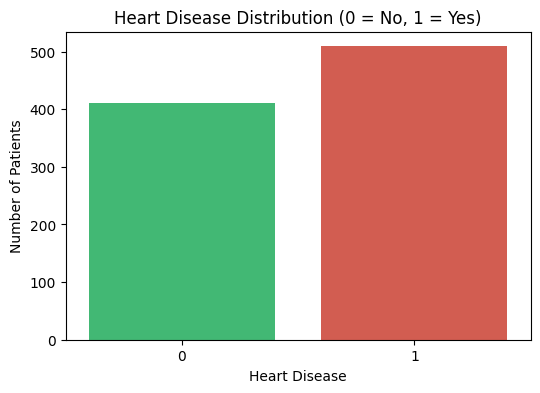

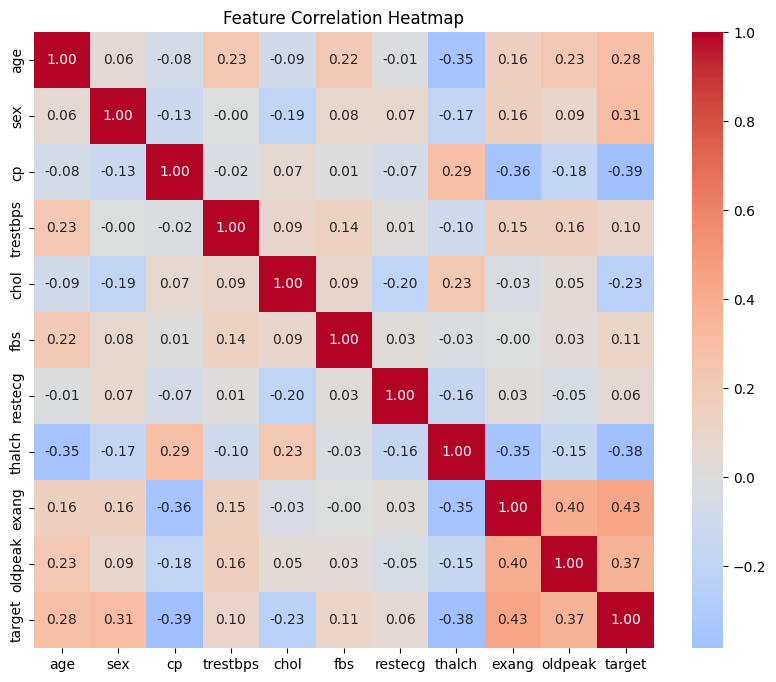


Correlation of each feature with target (sorted):
target      1.000000
exang       0.433605
oldpeak     0.366138
sex         0.307284
age         0.282700
fbs         0.108071
trestbps    0.101273
restecg     0.058783
chol       -0.228976
thalch     -0.381864
cp         -0.385077
Name: target, dtype: float64


In [10]:
# --- Chart 1: Target Distribution ---
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=heart_encoded, palette=['#2ecc71', '#e74c3c'])
plt.title('Heart Disease Distribution (0 = No, 1 = Yes)')
plt.xlabel('Heart Disease')
plt.ylabel('Number of Patients')
plt.show()

# --- Chart 2: Correlation Heatmap ---
plt.figure(figsize=(10, 8))
sns.heatmap(heart_encoded.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

# --- Bonus: Sorted correlations with target ---
print("\nCorrelation of each feature with target (sorted):")
print(heart_encoded.corr()['target'].sort_values(ascending=False))

**Step 10: Train-Test Split**

We split the data into:
- Features (X) — everything except the target column
- Target (y) — the target column

Then 80% goes to training (the model learns from this) and 20% to testing (we judge the model on this). The stratify parameter keeps the same disease ratio in both groups.

In [11]:
# Separate features (X) from target (y)
X = heart_encoded.drop('target', axis=1)
y = heart_encoded['target']

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Confirm the split
print("Training set shape:", X_train.shape)
print("Testing set shape :", X_test.shape)

print("\nTarget distribution in training set:")
print(y_train.value_counts())

print("\nTarget distribution in testing set:")
print(y_test.value_counts())

Training set shape: (736, 10)
Testing set shape : (184, 10)

Target distribution in training set:
target
1    407
0    329
Name: count, dtype: int64

Target distribution in testing set:
target
1    102
0     82
Name: count, dtype: int64


**Step 12: Feature Scaling**

Some features have small values (like 0 or 1) and others have big values (like cholesterol around 250). Logistic Regression is sensitive to this difference.

We use StandardScaler to put every column on the same scale — mean 0, standard deviation 1. This helps Logistic Regression work properly. Tree-based models don't need it, but scaling doesn't hurt them.

In [12]:
# Set up the scaler
scaler = StandardScaler()

# Fit and transform on training data, only transform on test data
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("Features scaled successfully.")
print("Training set shape:", X_train.shape)
print("Testing set shape :", X_test.shape)

Features scaled successfully.
Training set shape: (736, 10)
Testing set shape : (184, 10)


**Step 13: Train the 4 Models**

We train four classification algorithms on the scaled training data:

1. Logistic Regression — simple linear baseline
2. Decision Tree — yes/no flowchart of rules
3. Random Forest — 100 decision trees that vote
4. XGBoost — modern gradient boosting, often the most accurate

Each model learns patterns from the training data so it can predict heart disease in new patients.

In [13]:
# Set up all 4 models
log_model  = LogisticRegression(max_iter=1000, random_state=42)
tree_model = DecisionTreeClassifier(random_state=42)
rf_model   = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
xgb_model  = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')

# Train each one
print("Training Logistic Regression...")
log_model.fit(X_train, y_train)

print("Training Decision Tree...")
tree_model.fit(X_train, y_train)

print("Training Random Forest...")
rf_model.fit(X_train, y_train)

print("Training XGBoost...")
xgb_model.fit(X_train, y_train)

print("\nAll 4 models trained successfully.")

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [21:47:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



All 4 models trained successfully.


**Step 14: Evaluate the Models**

We test each trained model on the testing set and measure six things:
- Accuracy — overall percent correct
- Precision — when it says "sick", how often is it right
- Recall — of all sick people, how many were caught
- F1-Score — balance between precision and recall
- ROC-AUC — overall ability to separate sick from healthy
- Confusion Matrix — exact breakdown of correct vs wrong predictions

In medicine, Recall matters most — missing a sick patient is worse than a false alarm.


========== Logistic Regression ==========
Accuracy : 0.8207
ROC-AUC  : 0.8989

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.77      0.79        82
           1       0.82      0.86      0.84       102

    accuracy                           0.82       184
   macro avg       0.82      0.82      0.82       184
weighted avg       0.82      0.82      0.82       184



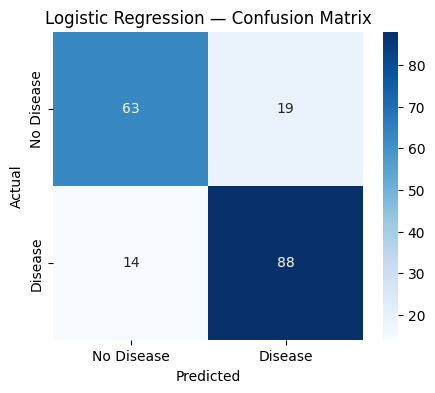


========== Decision Tree ==========
Accuracy : 0.7663
ROC-AUC  : 0.7629

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.73      0.74        82
           1       0.79      0.79      0.79       102

    accuracy                           0.77       184
   macro avg       0.76      0.76      0.76       184
weighted avg       0.77      0.77      0.77       184



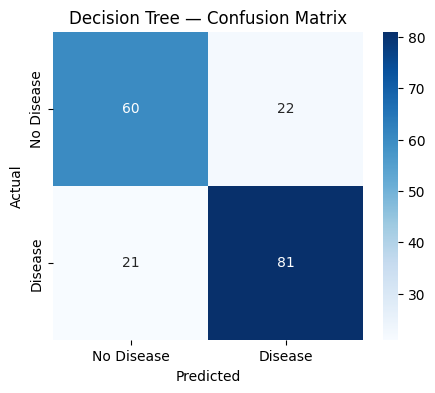


========== Random Forest ==========
Accuracy : 0.7989
ROC-AUC  : 0.9126

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.72      0.76        82
           1       0.79      0.86      0.83       102

    accuracy                           0.80       184
   macro avg       0.80      0.79      0.79       184
weighted avg       0.80      0.80      0.80       184



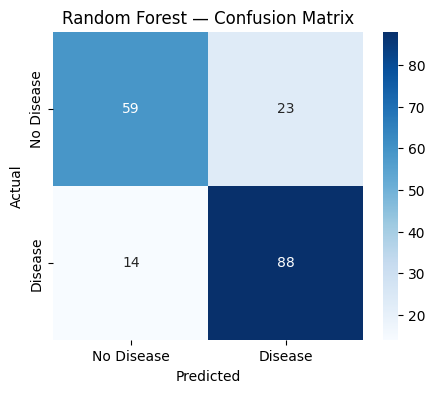


========== XGBoost ==========
Accuracy : 0.8370
ROC-AUC  : 0.8910

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.79      0.81        82
           1       0.84      0.87      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.83      0.83       184
weighted avg       0.84      0.84      0.84       184



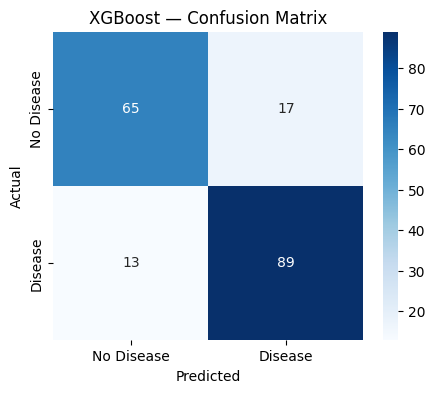

In [14]:
# Reusable evaluation function
def evaluate(name, model, X_test, y_test):
    # Get predictions
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Print core scores
    print(f"\n========== {name} ==========")
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion matrix as a heatmap
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'])
    plt.title(f'{name} — Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Evaluate all 4 models
evaluate("Logistic Regression", log_model, X_test, y_test)
evaluate("Decision Tree", tree_model, X_test, y_test)
evaluate("Random Forest", rf_model, X_test, y_test)
evaluate("XGBoost", xgb_model, X_test, y_test)

**Step 15: Compare ROC Curves**

We plot all 4 models' ROC curves on one chart for a visual comparison. The diagonal dashed line represents random guessing. The closer a curve is to the top-left corner, the better the model.

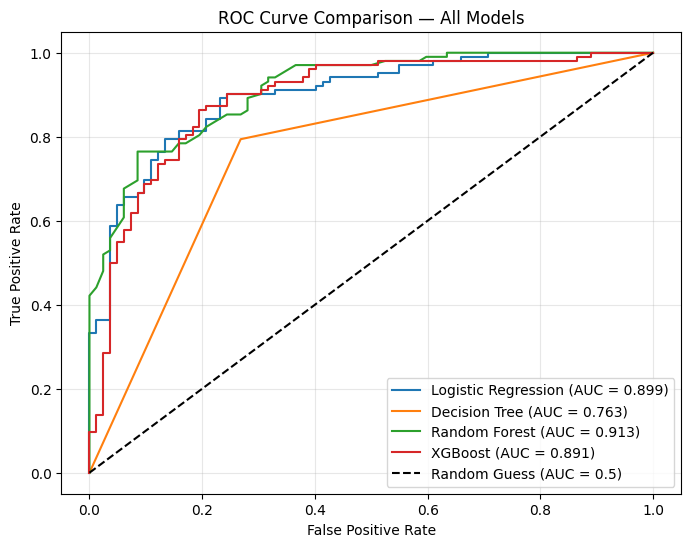

In [15]:
plt.figure(figsize=(8, 6))

# Loop through each model and plot its ROC curve
for name, model in [
    ('Logistic Regression', log_model),
    ('Decision Tree', tree_model),
    ('Random Forest', rf_model),
    ('XGBoost', xgb_model)
]:
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

# Random guess line
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison — All Models')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

**Step 16: Feature Importance**

We ask the best model (XGBoost) which features mattered most for predicting heart disease. This shows which health indicators are the strongest signals — useful insight for doctors.

Feature importance (ranked):
    Feature  Importance
2        cp    0.325778
1       sex    0.150447
8     exang    0.116756
9   oldpeak    0.068183
4      chol    0.066687
0       age    0.061796
5       fbs    0.060028
7    thalch    0.057603
6   restecg    0.051521
3  trestbps    0.041201


/tmp/ipykernel_6329/624311004.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


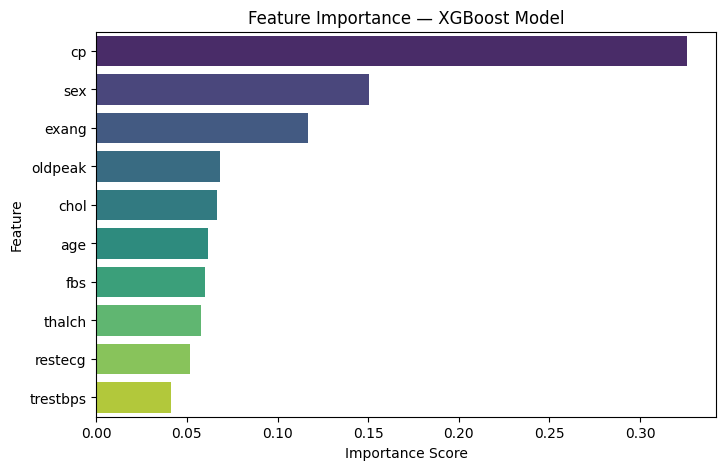

In [16]:
# Get feature names from the original columns (before scaling)
feature_names = heart_encoded.drop('target', axis=1).columns

# Get importance scores from XGBoost
importances = xgb_model.feature_importances_

# Put them in a sorted dataframe
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("Feature importance (ranked):")
print(importance_df)

# Visualize as a bar chart
plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Feature Importance — XGBoost Model')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

**Step 17: Deployment**

The trained XGBoost model was deployed as a live, interactive web application so anyone can test it through their browser without installing anything.

**Deployment Stack:**
- **Gradio** — used to build a clean, user-friendly interface with sliders, dropdowns, and radio buttons for each clinical input (age, blood pressure, cholesterol, chest pain type, etc.)
- **Hugging Face Spaces** — used as the free hosting platform to serve the model 24/7
- **Joblib** — used to serialize (save) the trained XGBoost model and the StandardScaler so they can be loaded by the deployed app

The interface accepts standard patient health indicators in plain English (e.g., "Typical Angina" instead of the encoded value `3`), applies the same preprocessing pipeline used during training, and returns:
- A binary prediction (High Risk / Low Risk)
- The probability percentage of having heart disease
- A clear medical disclaimer

**🔗 Live Demo:** https://huggingface.co/spaces/emm-xin19/CodeAlpha-HeartDiseasePrediction_AaminaKhan

**💻 GitHub Repository:** [insert your repo link here]

This step completes the full machine learning lifecycle: data preprocessing → model training → evaluation → deployment.

In [17]:
import joblib

# Save the best model (XGBoost) and the scaler
joblib.dump(xgb_model, 'xgb_heart_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model and scaler saved successfully.")
print("Files created:")
print("  - xgb_heart_model.pkl")
print("  - scaler.pkl")

# OPTIONAL: Download the files directly to your computer from Colab
from google.colab import files
files.download('xgb_heart_model.pkl')
files.download('scaler.pkl')


Model and scaler saved successfully.
Files created:
  - xgb_heart_model.pkl
  - scaler.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Step 18: Conclusion & Findings**

**Project Summary**
This project built a machine learning system to predict whether a patient is at risk of heart disease using the UCI Heart Disease dataset (920 patients combined from 4 hospitals: Cleveland, Hungary, Switzerland, and VA Long Beach). The target was binary — does the patient have heart disease (1) or not (0).

**Pipeline**
1. Loaded and inspected the dataset (920 rows × 16 columns)
2. Dropped non-medical columns (id, dataset)
3. Converted the multi-level severity column (num: 0–4) into a binary target
4. Handled missing values:
   - Dropped 3 columns with >30% missing data (ca, thal, slope)
   - Filled remaining numeric gaps with the median
   - Filled remaining categorical gaps with the mode
5. Encoded text columns (sex, cp, fbs, restecg, exang) into numeric form
6. Performed EDA to visualize target distribution and feature correlations
7. Stratified 80/20 train-test split
8. Standardized features with StandardScaler
9. Trained four classifiers: Logistic Regression, Decision Tree, Random Forest, and XGBoost
10. Evaluated with Accuracy, Precision, Recall, F1, ROC-AUC, and Confusion Matrix
11. Compared all four models with a combined ROC curve
12. Extracted feature importance from the best model
13. Deployed the final model as a live web application

**Model Results**

| Model | Accuracy | ROC-AUC | Recall (Disease) |
|---|---|---|---|
| Logistic Regression | 0.82 | 0.899 | 0.86 |
| Decision Tree | 0.77 | 0.763 | 0.79 |
| Random Forest | 0.80 | 0.913 | 0.86 |
| XGBoost | 0.84 | 0.891 | 0.87 |

**Best Model: XGBoost**
XGBoost was chosen as the best deployment model. It achieved the highest accuracy (84%) and the highest recall on the disease class (87%), meaning it correctly identified 89 out of 102 sick patients in the test set. In medical screening, recall is the most important metric because missing a sick patient (false negative) is far more dangerous than wrongly flagging a healthy one (false positive). Random Forest had the highest ROC-AUC (0.913), making it a strong alternative if calibrated probabilities matter more than raw predictions.

**Feature Importance Insights**
The XGBoost model identified the following top predictors of heart disease:
1. Chest pain type (cp) — 32.6%
2. Sex — 15.0%
3. Exercise-induced angina (exang) — 11.7%
4. ST depression (oldpeak) — 6.8%
5. Cholesterol (chol) — 6.7%

This aligns closely with clinical knowledge: the type of chest pain, presence of exercise angina, and ST depression on ECG are well-established cardiovascular risk indicators. The model essentially rediscovered what cardiologists already use in practice.

**Comparison with Task 1**
Unlike the Credit Scoring project (Task 1), where the features showed weak predictive signal (ROC-AUC near 0.5), this dataset contains genuinely informative clinical features. All four models achieved ROC-AUC above 0.76, and the top three exceeded 0.89. This demonstrates an important lesson in machine learning: model performance is fundamentally limited by the quality of the features in the dataset.

**Deployment**
The final XGBoost model was deployed as an interactive web application using **Gradio** for the interface and **Hugging Face Spaces** for free, browser-based hosting. The trained model and StandardScaler were serialized with Joblib and loaded by the deployed app, which accepts standard clinical inputs in plain English (e.g. "Typical Angina" instead of the encoded value 3), applies the same preprocessing pipeline used during training, and returns a binary risk prediction along with the probability percentage of heart disease.

🔗 **Live Demo:** https://huggingface.co/spaces/emm-xin19/CodeAlpha-HeartDiseasePrediction_AaminaKhan

**Conclusion**
The project successfully built a reliable heart disease prediction model with deployment-grade performance and shipped it as a live, accessible web tool. XGBoost is recommended as the production model, with chest pain type, sex, and exercise-induced angina being the most influential medical features. Future improvements could include hyperparameter tuning, more sophisticated handling of missing data (e.g., imputation with KNN), and integration of additional features like family history, smoking status, or BMI for even stronger predictions.